In [1]:
!pip install -q kaggle

from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d prithivsakthiur/deepfake-vs-real-20k
!unzip -q deepfake-vs-real-20k.zip -d dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/prithivsakthiur/deepfake-vs-real-20k
License(s): apache-2.0
100% 10.9G/10.9G [04:41<00:00, 41.7MB/s]



In [2]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)
    break

dataset


In [4]:
DATA_DIR = "/content/dataset/Deep-vs-Real"

IMG_SIZE = (300,300)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 19219 files belonging to 2 classes.
Using 15376 files for training.
Found 19219 files belonging to 2 classes.
Using 3843 files for validation.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

In [7]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300,300,3)
)

base_model.trainable = False

inputs = layers.Input(shape=(300,300,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,264 (42.64 MB)

 Trainable params: 393,729 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [10]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    ),

    ModelCheckpoint(
        "deepshield_best.h5",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9686 - loss: 0.0856

481/481 ━━━━━━━━━━━━━━━━━━━━ 311s 646ms/step - accuracy: 0.9668 - loss: 0.0879 - val_accuracy: 0.9698 - val_loss: 0.0783 - learning_rate: 0.0010
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9729 - loss: 0.0685

481/481 ━━━━━━━━━━━━━━━━━━━━ 314s 629ms/step - accuracy: 0.9719 - loss: 0.0723 - val_accuracy: 0.9776 - val_loss: 0.0553 - learning_rate: 0.0010
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 320s 625ms/step - accuracy: 0.9732 - loss: 0.0708 - val_accuracy: 0.9774 - val_loss: 0.0562 - learning_rate: 0.0010
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.9762 - loss: 0.0613

481/481 ━━━━━━━━━━━━━━━━━━━━ 274s 569ms/step - accuracy: 0.9756 - loss: 0.0637 - val_accuracy: 0.9815 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 5/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 274s 569ms/step - accuracy: 0.9754 - loss: 0.0665 - val_accuracy: 0.9766 - val_loss: 0.0594 - learning_rate: 0.0010
Epoch 6/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 275s 573ms/step - accuracy: 0.9772 - loss: 0.0585 - val_accuracy: 0.9766 - val_loss: 0.0595 - learning_rate: 0.0010
Epoch 7/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 279s 579ms/step - accuracy: 0.9802 - loss: 0.0526 - val_accuracy: 0.9797 - val_loss: 0.0546 - learning_rate: 2.0000e-04
Epoch 8/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9809 - loss: 0.0496

481/481 ━━━━━━━━━━━━━━━━━━━━ 293s 610ms/step - accuracy: 0.9814 - loss: 0.0508 - val_accuracy: 0.9797 - val_loss: 0.0481 - learning_rate: 2.0000e-04
Epoch 9/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 285s 593ms/step - accuracy: 0.9811 - loss: 0.0509 - val_accuracy: 0.9805 - val_loss: 0.0535 - learning_rate: 2.0000e-04
Epoch 10/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 284s 590ms/step - accuracy: 0.9819 - loss: 0.0483 - val_accuracy: 0.9813 - val_loss: 0.0502 - learning_rate: 2.0000e-04


In [11]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 346s 664ms/step - accuracy: 0.9475 - loss: 0.1508 - val_accuracy: 0.9794 - val_loss: 0.0573
Epoch 2/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 292s 607ms/step - accuracy: 0.9661 - loss: 0.0895 - val_accuracy: 0.9836 - val_loss: 0.0461
Epoch 3/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 283s 588ms/step - accuracy: 0.9741 - loss: 0.0701 - val_accuracy: 0.9849 - val_loss: 0.0409
Epoch 4/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 282s 586ms/step - accuracy: 0.9793 - loss: 0.0546 - val_accuracy: 0.9872 - val_loss: 0.0341
Epoch 5/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 284s 590ms/step - accuracy: 0.9829 - loss: 0.0476 - val_accuracy: 0.9896 - val_loss: 0.0286
Epoch 6/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 308s 639ms/step - accuracy: 0.9843 - loss: 0.0442 - val_accuracy: 0.9896 - val_loss: 0.0276
Epoch 7/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 282s 585ms/step - accuracy: 0.9879 - loss: 0.0348 - val_accuracy: 0.9904 - val_loss: 0.0252
Epoch 8/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 280s 582ms/step - accuracy: 0.9873 -

In [12]:
loss, acc = model.evaluate(val_ds)

print("Validation Accuracy:", acc)

121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 404ms/step - accuracy: 0.9953 - loss: 0.0166
Validation Accuracy: 0.9953161478042603


In [ ]:
model.save("DeepShield_EfficientNetB3.h5")

In [17]:
import os
print(os.path.exists("DeepShield_EfficientNetB3.h5"))

True


In [18]:
from google.colab import files
files.download("DeepShield_EfficientNetB3.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/DeepShield_EfficientNetB3.h5')

Mounted at /content/drive


In [14]:
from google.colab import files
files.download("DeepShield_EfficientNetB3.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("DeepShield.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpgu9srj5t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='keras_tensor_385')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139274514538256: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139274514543440: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139274908178128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139274908183120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139274908182736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139274908183888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139274908181584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139274908181776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139274908185040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139274908185232: TensorSpec(shape=(), dtype=tf.resource, name=

In [23]:
from tensorflow.keras.preprocessing import image

img_path = "/content/test.jpg"

img = image.load_img(img_path, target_size=(300,300))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)

pred = model.predict(img)[0][0]

if pred > 0.5:
    print("REAL")
else:
    print("DEEPFAKE")

print("Confidence:", float(pred))

FileNotFoundError: [Errno 2] No such file or directory: '/content/test.jpg'

In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=(300,300),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=(300,300),
    batch_size=32
)

Found 19219 files belonging to 2 classes.
Using 13454 files for training.
Found 19219 files belonging to 2 classes.
Using 5765 files for validation.


In [24]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Fake", "Real"]
))

              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      1891
        Real       0.99      1.00      1.00      1952

    accuracy                           1.00      3843
   macro avg       1.00      1.00      1.00      3843
weighted avg       1.00      1.00      1.00      3843



In [26]:
from sklearn.metrics import roc_auc_score

y_prob = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_prob.extend(preds.flatten())

auc = roc_auc_score(y_true, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.5196372105573424


In [27]:
print(min(y_prob))
print(max(y_prob))
print(y_prob[:10])

7.257983e-14
1.0
[np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0005606776), np.float32(2.9211746e-05), np.float32(4.5379387e-05), np.float32(1.0), np.float32(1.0), np.float32(5.763158e-06)]


In [30]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

y_true = []
y_prob = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_prob.extend(preds.flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = (y_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_prob))

print(classification_report(
    y_true,
    y_pred,
    target_names=["Deepfake", "Real"]
))

Accuracy: 0.9953161592505855
ROC-AUC: 0.9998439545387556
              precision    recall  f1-score   support

    Deepfake       1.00      0.99      1.00      1891
        Real       0.99      1.00      1.00      1952

    accuracy                           1.00      3843
   macro avg       1.00      1.00      1.00      3843
weighted avg       1.00      1.00      1.00      3843



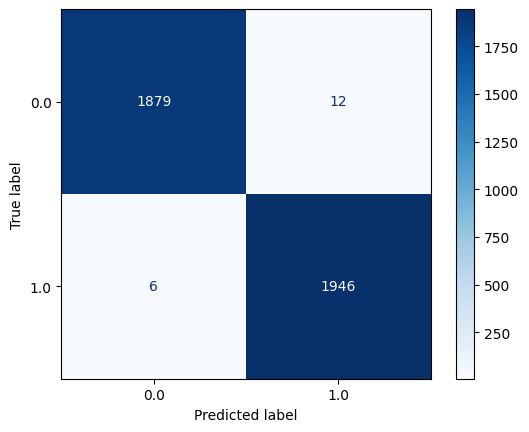

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    cmap="Blues"
)
plt.show()